# Testing out Point Defects
Schottky defect

## Testing Point Defects in Ice using ECM

Generate ice block of appropriate size.

In [1]:
from jax.lax import switch
from tracemalloc import stop
import os
from typing import Literal
from ase.io import read, write
from ase.build import find_optimal_cell_shape
from ase.build import make_supercell
from ase.visualize.plot import plot_atoms
import numpy as np
import veloxchem.ensembledriver
import veloxchem.ensembleparser
import pandas as pd

#from pymodule.ECM_test.tempfiles.main import PDB_FILE, QM_RESNAME
    
PossiblePhases = Literal['1h', '1c']    
def generate_ice_block(path, phase: PossiblePhases, cell_dimensions, unit_cell_filename, target_supercell_shape, target_supercell_size, write_to_pdb = True, plot = True):
    super_cell_filename = f'{phase}x{cell_dimensions[0]}{cell_dimensions[1]}{cell_dimensions[2]}_supercell'
    # Generate unit.
    os.system(f'mkdir {path}')
    # os.system('ls')
    os.system(f'genice2 --rep {cell_dimensions[0]} {cell_dimensions[1]} {cell_dimensions[2]} {phase} --format cif > {path}/{unit_cell_filename}.cif')

    # Make Atoms obj. 
    ice = read(
        filename=(f'{path}/{unit_cell_filename}.cif')
        )

    # print(np.asarray(cell))
    P = find_optimal_cell_shape(
        cell=ice.cell, 
        target_size=target_supercell_size,
        target_shape=target_supercell_shape
        )

    ice_block = make_supercell(prim=ice,P=P,)
    
    if write_to_pdb:
        pdb_file = f'{path}/{super_cell_filename}.pdb'
        write(f'{pdb_file}', ice_block)
    
    if plot:
        plot_atoms(ice_block)

# TODO: Generalize this function to output more geometry parameters if necessary
def get_space_dimensions(filename = None, ):
    
    supercell = read(f'{filename}')
    np_supercell = np.array(supercell)

    x = 0
    y = 0
    z = 0
    for i in np_supercell:
        ix, iy, iz = i.position
        if ix > x:
            x = ix
        if iy > y:
            y = iy
        if iz > z:
            z = iz
        print(ix)
    print(x, y, z)
    return [x, y, z]

# TODO: Simplify to output all indecies in QM region. 
def get_centeroid_region(filename = None, cuboid_threshold = None, print_ctrl=True, target_atom_symbol='O', residue_len=1):
    '''
    Param:
        filename: Takes path string of pdb or cif file. 
        cuboid_threshold: Decimal margin from center to the edge of the cuboid QM region.
        print_ctrl: Set true to print real-time deduction status.
        target_atom_symbol=List of strings or just string of a single atom symbol that 
    '''
    supercell = read(f'{filename}')
    np_supercell = np.array(supercell)

    x, y, z = get_space_dimensions(filename)
    
    midpoint = [x/2, y/2, z/2]
    
    x_position_threshold = [ (midpoint[0]-x*cuboid_threshold), (midpoint[0]+x*cuboid_threshold) ]
    y_position_threshold = [ (midpoint[1]-y*cuboid_threshold), (midpoint[1]+y*cuboid_threshold) ]
    z_position_threshold = [ (midpoint[2]-z*cuboid_threshold), (midpoint[2]+z*cuboid_threshold) ]

    candidate_qm = [] # list of indecies of atoms in the same moelcule.
    
    if print_ctrl:
        print(f'1 \t IDENTIFYING CANDIDATE MOLECULES FOR THE QM REGION \n')
        print(f'\n')
        #print(f' ATOMS ARRAY: \n\n {ice_block_ar}')
        print(f'\n')
        print(f'2 \t SEARCH CONFIG: ')
        print(f'\n')
        print(f'\t Lenghts:')
        print(f'\n')
        print(f'\t\t x axis: {x} \n \t\t y axis: {y}, \n \t\t z axis {z}')
        print(f'\n')
        print(f'\t Threshold configuration')
        print(f'\n')
        print(f'\t Cuboid threshold parameters: {100*cuboid_threshold} % (for all axes).')
        print(f'\n')
        print(f'\t Thresholds:')
        print(f'\n')
        print(f'\t\t x axis: {x_position_threshold} \n \t\t y axis: {y_position_threshold}, \n \t\t z axis {z_position_threshold}')

        print(f'\n')
        print(f'3 \t IDENTIFYING CANDIDATE ATOMS')

    c = -1
    skip_count = 0
    for i in np_supercell:              # Access each individual atom. 
        c += 1                          # Count up
        if skip_count > 0: 
            skip_count -= 1
            continue
        if(i.symbol not in target_atom_symbol):
            continue
        ix, iy, iz = i.position         # Isolate atom coordinates
        if(ix < x_position_threshold[0] or ix > x_position_threshold[1]):           # Validate position
            continue
        else:
            if(iy < y_position_threshold[0] or iy > y_position_threshold[1]):       # Validate position
                continue
            else:
                if(iz < z_position_threshold[0] or iz > z_position_threshold[1]):   # Validate position
                    continue
                else:

                    # 1. Validate                                                
                    for r in range(residue_len):                # Ensure that suffiecnt atoms are marked.
                        candidate_qm.append(i.index + r + 1)    # Append main indecies and indecies chained through the residue in one go.
                        skip_count = residue_len - 1            # Do not append the indecies in the residue chain.
                    if print_ctrl:
                        print(f'ACCEPTED: Added candidate molecule with atom indeceies {c}, {c+1}, {c+2}')
    print(f'\n')
    print(f'RESULTS: Candidate atoms list:\n')
    print(f'\tNr. of candidates: {len(candidate_qm)}\n')
    for i in candidate_qm:
        print(f'\t{i} ') #{i}\n')
    return candidate_qm

# def process_pdb(filename , atoms_per_mol, target_filename , global_resname, qm_resname, qm_indecies, atom_type_resnames):
#     with open(filename) as f:
#         lines = f.readlines()

#     atom_count = 0
#     out = []
#     for line in lines:
#         if line.startswith('ATOM'):
#             if global_resname != None:
#                 curr_resname = global_resname
#             elif atom_type_resnames != None:
#                 curr_resname = atom_type_resnames[f'{(line[12:16].strip())}']
#             mol_idx = atom_count//atoms_per_mol
#             res_num = (mol_idx % 9999) + 1 # PDB resid wraps at 9999 
#             if atom_count in qm_indecies:
#                 curr_resname = qm_resname
#             line = line[:17] + f'{curr_resname:>3s}' + line[20:22] + f'{res_num:4d}' + line[26:]
#             atom_count +=1
#             out.append(line)
#     with open(target_filename, 'w') as f:
#         f.writelines(out)

# TODO: Better process pdb files. Use regex to associate atoms with right resiude. Use regex to set encolesed moelcules in QM region to QM resname. 
# NOTE: Big problem, what are the stages of pdb processing? What processing is necessary, what are the different usecases?. Goal: Build a general pdb parser that can be used for the ensembleparsers and multiple different file types. One problem for instance is when the there are non-target residues and atoms around and between target atoms for QM consideration. 
# NOTE: Make a usecase diagram for types of problems. Try to generalize both water, database crystals and ionic crystals. What is similar what is different. 
# TODO: !!! TING then try to see what processing and calculation steps there are. I.e. (1) identifying centroid region, (2) porcessing the crystal, (3) continously preparaing the pdb file. NOTE we might to first handle the cif file when unwrapping, then calcualte centroid, then convert to pdb, and process accordinggly, start by building a general processor for these steps.

def process_pdb(filename, patterns, qm_ids=None, qm_resname=None):
    """
    Process a PDB file, assigning residue names and unique residue numbers
    to atoms matching specified patterns.

    Args:
        filename:   Path to the PDB file.
        patterns:   Dict mapping residue names to atom symbol patterns.
                    e.g. {'WAT': [' O', ' H', ' H'], 'ION': [' Na']}
        qm_ids:     Optional list of line indices whose residue name
                    should be overridden with qm_resname.
        qm_resname: Residue name for QM-region molecules (e.g. 'LIG').
    """
    if qm_ids is None:
        qm_ids = []

    print(f'Processing {filename}')
    with open(filename) as f:
        lines = f.readlines()

    # Identify ATOM data region
    start_idx = None
    end_idx = None
    for i, line in enumerate(lines):
        if line.startswith('ATOM'):
            if start_idx is None:
                start_idx = i
            end_idx = i

    if start_idx is None:
        print('No ATOM lines found.')
        return

    print(f'Data row index limits: Start, {start_idx}; End, {end_idx}')

    # Extract atom symbols from the ATOM region
    symbols = [line[14:16] for line in lines[start_idx:end_idx + 1]]

    # Find all matching segments for every pattern
    matches = []  # (line_index, pattern_length, resname)
    for resname, pattern in patterns.items():
        for idx in _find_pattern(symbols, pattern, offset=start_idx):
            matches.append((idx, len(pattern), resname))

    # Sort by line index so residue numbers are assigned in file order
    matches.sort(key=lambda x: x[0])
    print(f'Found {len(matches)} matching segments.')

    # Assign residue names and unique residue numbers
    res_num = 2  # start at 2 so unmatched atoms stay at 1
    for seg_idx, pat_len, resname in matches:
        res_num_str = f'{res_num:>4}'  # right-justified, 4 chars (PDB cols 23-26)

        residue_name = resname
        if seg_idx in qm_ids and qm_resname is not None:
            residue_name = qm_resname

        for i in range(pat_len):
            line = lines[seg_idx + i]
            # cols: [:17] record+serial+name | [17:20] resname | [20:22] blank+chain | [22:26] resseq | [26:] rest
            lines[seg_idx + i] = line[:17] + residue_name + line[20:22] + res_num_str + line[26:]

        res_num += 1

    with open(filename, 'w') as f:
        f.writelines(lines)
    print(f'Done. Assigned {res_num - 2} residues.')


def _find_pattern(symbols, pattern, offset=0):
    """
    Find all non-overlapping occurrences of pattern in symbols.
    Returns a list of absolute line indices (adjusted by offset).
    """
    matches = []
    i = 0
    while i <= len(symbols) - len(pattern):
        if symbols[i:i + len(pattern)] == pattern:
            matches.append(i + offset)
            i += len(pattern)  # skip past this match to avoid overlap
        else:
            i += 1
    return matches


    # atom_count = 0
    # out = []
    # for line in lines:
    #     if line.startswith('ATOM') or line.startswith('HETATM'):
    #         # 1) Determine residue name
    #         curr_resname = global_resname  # may be None

    #         if atom_type_resnames and atom_count not in qm_indecies:
    #             # Extract atom name from cols 12-16 (reliable in ASE PDBs)
    #             atom_name = line[12:16].strip()
    #             # Also try element from cols 76-78 as fallback
    #             atom_symbol = line[76:78].strip() if len(line) >= 78 else ''

    #             # Try matching by symbol first, then by atom name
    #             if atom_symbol in atom_type_resnames:
    #                 curr_resname = atom_type_resnames[atom_symbol]
    #             elif atom_name in atom_type_resnames:
    #                 curr_resname = atom_type_resnames[atom_name]

    #         # 2) QM atoms always override
    #         if atom_count in qm_indecies:
    #             curr_resname = qm_resname

    #         # 3) Safety check
    #         if curr_resname is None:
    #             raise ValueError(
    #                 f"Could not determine residue name for atom {atom_count}: {line.strip()}\n"
    #                 f"Set global_resname or provide atom_type_resnames mapping."
    #             )

    #         mol_idx = atom_count // atoms_per_mol
    #         res_num = (mol_idx % 9999) + 1

    #         # Fix atom name to uppercase to match PE database expectations
    #         atom_name = line[12:16].strip().upper()
    #         line = line[:12] + f'{atom_name:>4s}' + line[16:]
    #         line = line[:17] + f'{curr_resname:>3s}' + line[20:22] + f'{res_num:4d}' + line[26:]
    #         atom_count += 1
    #         out.append(line)
    # with open(target_filename, 'w') as f:
    #     f.writelines(out)
    
def del_atoms_pdb(filename, output_filename, atom_indecies):
    with open(filename) as f:
        lines = f.readlines()

    atom_count = 0
    out = []
    for line in lines:
        if line.startswith('ATOM'):
            if atom_count not in atom_indecies:
                out.append(line)
            atom_count +=1
    with open(output_filename, 'w') as f:
        f.writelines(out)
    
def calc_energy(filename, qm_resname, pe_cutoff=6.0, npe_cutoff=None, qm_charge=0, qm_multiplicity=1):
    ep = veloxchem.ensembleparser.EnsembleParser()   
    ed = veloxchem.ensembledriver.EnsembleDriver()
    ensemble = ep.structures(
        trajectory_file = f"{filename}",
        num_snapshots = None, 
        qm_region = f"resname {qm_resname}", 
        pe_cutoff = pe_cutoff,
        npe_cutoff=npe_cutoff
    )

    ed.set_env_models(pe_model = 'SEP', npe_model='tip3p')

    # TODO: Testa att sätta ed.xcfun = 'B3LYP'

    scf_results = ed.compute(ensemble, basis_set = '6-31G', qm_charge=qm_charge, qm_multiplicity=qm_multiplicity)
    return scf_results

/opt/anaconda3/envs/vlxenv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
UNIT_CELL_DIMENSIONS = (2,1,1)
# SUPERCELL_SIZE = 12 # Nr. Atoms
# SUPERCELL_SHAPE = 'sc'

PATH = 'tempfiles'
GENERAL_FILE_NAME = f'1hx{UNIT_CELL_DIMENSIONS[0]}{UNIT_CELL_DIMENSIONS[1]}{UNIT_CELL_DIMENSIONS[2]}'
# SUPERCELL_FILE_NAME = f'{GENERAL_FILE_NAME}_supercell'
PDB_FILE = f'{PATH}/{GENERAL_FILE_NAME}.pdb'

# PROCESSING PDB FILE
ATOMS_PER_MOL = 3
GLOBAL_RESNAME = 'WAT'
QM_RESNAME = 'LIG'

# DEFECT SPECIFICATIONS
DEL_INDECIES = [27,28,29]
DEFECT_PDB_FILE = f'{PATH}/defect_{GENERAL_FILE_NAME}.pdb'



In [3]:
# generate_ice_block(
#     plot = False,
#     write_to_pdb=True, 
#     path = PATH, 
#     cell_dimensions = UNIT_CELL_DIMENSIONS, 
#     unit_cell_filename = GENERAL_FILE_NAME, 
#     target_supercell_shape = SUPERCELL_SHAPE, 
#     target_supercell_size = SUPERCELL_SIZE
# )

# The above is deprecated. I need to create a supercell with the correct topology.
os.system(f'genice2 --rep {UNIT_CELL_DIMENSIONS[0]} {UNIT_CELL_DIMENSIONS[1]} {UNIT_CELL_DIMENSIONS[2]} 1h --format cif > {PATH}/{GENERAL_FILE_NAME}.cif')
atoms = read(f'{PATH}/{GENERAL_FILE_NAME}.cif')
write(f'{PDB_FILE}', atoms)



INFO:__init__: Constructor of GenIce.
INFO:Cell dimension:
INFO:  a = 7.84813412606925
INFO:  b = 7.37735062301457
INFO:  c = 9.06573834219084
INFO:  A = 90.0
INFO:  B = 90.0
INFO:  C = 90.0
INFO:  Reshaping the unit cell.
INFO:    i:[2 0 0]
INFO:    j:[0 1 0]
INFO:    k:[0 0 1]
INFO:  Reshaped cell:
INFO:    a,b,c = 15.6962682521385, 7.37735062301457, 9.06573834219084
INFO:    A,B,C = 90.0, 90.0, 90.0
INFO:  
INFO:  Command line: /opt/anaconda3/envs/vlxenv/bin/genice2 --rep 2 1 1 1h --format cif
INFO:HB connectivity is not defined.
INFO:Bond length (specified): 3
INFO:Target Density: 0.92
INFO:Original Density: 0.0009111328713390615
INFO:Bond length (scaled, nm): 0.29903306849378936
INFO:__init__: end.
INFO:__init__: 3 ms
INFO:Stage1: Replicate water molecules to make a repeated cell.
INFO:  Number of water molecules: 32
INFO:  Pairs are not given explicitly.
INFO:  Estimating the bonds according to the pair distances.
INFO:  Number of water nodes: 16
INFO:Cell dimension:
INFO:  a = 1

Unwrap the crystal structure

Identify centroid molcuels to set as QM region

In [4]:
# Read from PDB to maintain coordiate standards.

candidate_qm_water = get_centeroid_region(
    #print_status=False, 
    filename=PDB_FILE, 
    cuboid_threshold = 0.2, 
    target_atom_symbol='O',
    residue_len=3,
    )


9.2
8.284
9.157
13.099
13.516
12.207
14.435
13.953
13.953
13.047
13.058
13.507
10.411
9.998
11.309
10.428
10.467
11.345
13.1
12.182
13.067
12.994
13.469
13.469
9.146
9.606
9.157
9.2
9.613
8.3
10.536
10.051
10.049
10.464
10.007
10.453
14.364
13.911
14.358
14.313
15.203
13.898
14.33
14.355
15.25
9.095
9.569
9.563
1.35
0.458
1.768
5.224
5.238
5.679
6.587
6.125
6.551
5.276
5.695
4.384
2.588
3.486
2.175
2.686
2.65
2.225
5.251
5.661
4.354
5.197
5.653
5.227
1.295
1.78
1.782
1.402
1.366
0.487
2.632
2.212
3.523
2.641
2.184
2.63
6.568
6.094
6.094
6.462
6.518
7.374
6.532
7.432
6.119
1.297
1.328
1.748
15.25 7.29 8.632
1 	 IDENTIFYING CANDIDATE MOLECULES FOR THE QM REGION 





2 	 SEARCH CONFIG: 


	 Lenghts:


		 x axis: 15.25 
 		 y axis: 7.29, 
 		 z axis 8.632


	 Threshold configuration


	 Cuboid threshold parameters: 20.0 % (for all axes).


	 Thresholds:


		 x axis: [np.float64(4.574999999999999), np.float64(10.675)] 
 		 y axis: [np.float64(2.187), np.float64(5.103)], 
 		 z axis [np.flo

1. Edit PDB file and set QM region based on the results above. 

In [6]:
# process_pdb(
#     filename=PDB_FILE,
#     # atoms_per_mol=ATOMS_PER_MOL,
#     #target_filename=PDB_FILE,
#     pattern = [' O', ' H', ' H'],
#     global_resname='WAT',
#     qm_resname='LIG',
#     qm_ids=candidate_qm_water,
#)

process_pdb(
    filename='tempfiles/1hx211.pdb',
    patterns={'WAT': [' O', ' H', ' H']},
    qm_ids=candidate_qm_water,
    qm_resname='LIG'
)


Processing tempfiles/1hx211.pdb
Data row index limits: Start, 2; End, 97
Found 32 matching segments.
Done. Assigned 32 residues.


2. Run through ensemble parser.

In [ ]:
print("1. \t Ensemble parser instance created.")

scf_results = calc_energy(filename=PDB_FILE, qm_resname=QM_RESNAME, pe_cutoff=6.0, npe_cutoff=None)

Del specific atom

In [ ]:
# defect_ice_block = ice_block
del_atoms_pdb(
    filename=PDB_FILE,
    output_filename=DEFECT_PDB_FILE,
    atom_indecies=[28,29,30]
)

DEFECT_PDB_FILE

Calculate new energy

In [ ]:
import veloxchem.ensembledriver
import veloxchem.ensembleparser

ep = veloxchem.ensembleparser.EnsembleParser()   
ed = veloxchem.ensembledriver.EnsembleDriver()

print("1. \t Ensemble parser instance created.")

defect_scf_results = calc_energy(
    filename=DEFECT_PDB_FILE, 
    qm_resname=QM_RESNAME, 
    pe_cutoff=6.0, 
    npe_cutoff=None,
    )

Calculate Chemical Potential

In [ ]:
# defect_ice_block = ice_block
indices = list(range(1, 26)) + list(range(30, 98))
del_atoms_pdb(
    filename=PDB_FILE,
    output_filename=f'{PATH}/1hx211_chem_pot.pdb',
    atom_indecies=indices
)

ep = veloxchem.ensembleparser.EnsembleParser()   
ed = veloxchem.ensembledriver.EnsembleDriver()

print("1. \t Ensemble parser instance created.")

chem_pot_scf_results = calc_energy(
    filename=f'{PATH}/1hx211_chem_pot.pdb', 
    qm_resname=QM_RESNAME, 
    pe_cutoff=6.0, 
    npe_cutoff=None,
    )


Calculate energy difference

In [ ]:
undistr_energy = scf_results['scf_all'][0][1]['scf_energy']
disturbed_energy = defect_scf_results['scf_all'][0][1]['scf_energy']
chemi_pot = chem_pot_scf_results['scf_all'][0][1]['scf_energy']

print(f'Energies: \n \t No Defect Lattice: {undistr_energy} \n \t Defect Lattice: {disturbed_energy}\n \t Diff: {disturbed_energy-undistr_energy+chemi_pot} Hartree or \n \t {(disturbed_energy-undistr_energy+chemi_pot)*27} eV/mol')

plot_atoms(read(PDB_FILE))
plot_atoms(read(DEFECT_PDB_FILE))

## Testing Point Defect in Ice 1h using SCF_driver (Draft)

In [ ]:
from veloxchem import scfdriver



## Testing Point Defects in NaCl (ionic and pair defects)

In [7]:
from ase.build import bulk
from ase.spacegroup import crystal
from ase.build import find_optimal_cell_shape
from ase.build import make_supercell
from ase.visualize.plot import plot_atoms
from ase.io import read, write

9.555652811707567
11.00347899529962
10.424348521862804
0.8686957101552366
11.293044232018037
1.737391420310471
10.134783285144392
0.5791304734368271
11.003478995299625
1.447826183592056
10.71391375858121
1.158260946873645
8.397391864833924
9.845218048425982
9.26608757498916
10.713913758581212
10.134783285144392
11.582609468736448
7.239130917960277
8.686957101552332
8.107826628115511
9.55565281170757
8.976522338270746
10.424348521862804
9.845218048425979
11.293044232018035
10.713913758581214
12.161739942173266
7.818261391397099
9.266087574989157
8.686957101552336
10.134783285144392
9.555652811707567
11.003478995299623
10.424348521862802
11.872174705454858
11.293044232018035
0.2895652367184107
8.39739186483392
9.845218048425979
9.266087574989157
10.713913758581212
10.134783285144392
11.582609468736447
11.003478995299627
1.447826183592056
11.872174705454853
0.8686957101552333
8.976522338270744
10.424348521862802
9.845218048425979
11.293044232018035
10.713913758581212
1.1582609468736444
11

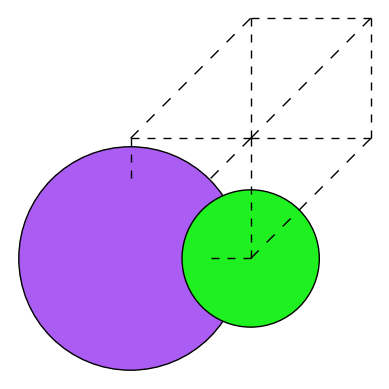

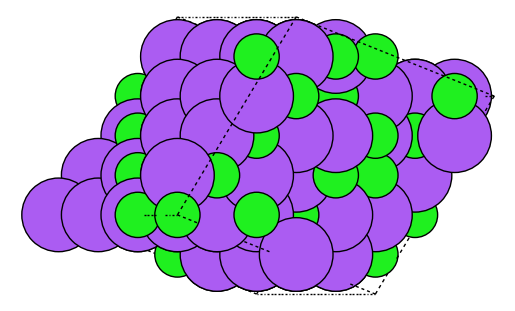

In [8]:
PATH = PATH
NACL_GENERAL_FILE_NAME = 'supercell_nacl'
# nacl = crystal(
#     symbols='NaCl', 
#     basis=[[0,0,0]],#, [0,1,0]],
#     spacegroup=227,
#     cellpar=[1,1,1, 90, 90, 90],
#     size=(2,2,2)
#     )

nacl = bulk('NaCl', 'rocksalt', a=3.57)

plot_atoms(nacl)

P = find_optimal_cell_shape(
    cell = nacl.cell,
    target_shape='sc',
    target_size=100
    )

supercell_nacl = make_supercell(nacl, P)

plot_atoms(supercell_nacl)

write(filename=f'{PATH}/{NACL_GENERAL_FILE_NAME}.cif', images=supercell_nacl, format='cif')

candidate_qm_nacl = get_centeroid_region(f'{PATH}/{NACL_GENERAL_FILE_NAME}.cif', cuboid_threshold=0.1, target_atom_symbol=['Na', 'Cl'], residue_len=2)


In [12]:
# Writes supercell to a file
write(filename=f'{PATH}/{NACL_GENERAL_FILE_NAME}.pdb', images=supercell_nacl)

# # Processes that file
# process_pdb(
#     filename=f'{PATH}/{NACL_GENERAL_FILE_NAME}.pdb',
#     atoms_per_mol=1,
#     target_filename=f'{PATH}/{NACL_GENERAL_FILE_NAME}.pdb',
#     qm_resname='LIG',
#     qm_indecies=candidate_qm_nacl,
#     global_resname=None,
#     atom_type_resnames={'NA':'NA', 'CL':'CL'}
# )

process_pdb(
    filename=f'{PATH}/{NACL_GENERAL_FILE_NAME}.pdb',
    patterns={' NA':['Na'], ' CL':['Cl']},
    qm_ids=candidate_qm_nacl,
    qm_resname='LIG'
)


# Calculate qm_charge and multiplicity
supercell_nacl = read(f'{PATH}/{NACL_GENERAL_FILE_NAME}.cif')
np_supercell = np.array(supercell_nacl)

n = sum(1 for idx in candidate_qm_nacl if np_supercell[idx].symbol == 'Na')
m = sum(1 for idx in candidate_qm_nacl if np_supercell[idx].symbol == 'Cl')
qm_charge = n - m

# Calculates supercell energy from the file
nacl_scf_results = calc_energy(
    filename=f'{PATH}/{GENERAL_FILE_NAME}.pdb',
    qm_resname='LIG',
    qm_charge=qm_charge,           # net charge of the QM region
    qm_multiplicity=1,           # should be fine if total electrons are even
    pe_cutoff=0.6,
    npe_cutoff=None
)

Processing tempfiles/supercell_nacl.pdb
Data row index limits: Start, 2; End, 201
Found 200 matching segments.
Done. Assigned 200 residues.
                                                                                                                          
                                            Self Consistent Field Driver Setup                                            
                                                                                                                          
                   Wave Function Model             : Spin-Restricted Hartree-Fock                                         
                   Initial Guess Model             : Superposition of Atomic Densities                                    
                   Convergence Accelerator         : Two Level Direct Inversion of Iterative Subspace                     
                   Max. Number of Iterations       : 50                                                                   

Del an ion

In [ ]:
# Define defect supercell file name
DEFECT_NACL_GENERAL_FILE_NAME = f'defect_{NACL_GENERAL_FILE_NAME}'

# Copy the undisturbed supercell
defect_nacl = read(f'{PATH}/{NACL_GENERAL_FILE_NAME}.pdb')

# Delete one atom
del defect_nacl[77]

# Write the dsiturbed supercell to a new file:
write(f'{PATH}/{DEFECT_NACL_GENERAL_FILE_NAME}.cif', images=defect_nacl)
write(f'{PATH}/{DEFECT_NACL_GENERAL_FILE_NAME}.pdb', images=defect_nacl)

# Identify new qm_candidates (might be a logical bug here)
candidate_qm_defect_nacl = get_centeroid_region(f'{PATH}/{DEFECT_NACL_GENERAL_FILE_NAME}.cif', cuboid_threshold=0.1, target_atom_symbol=['Na', 'Cl'], residue_len=2)


# Process that pdb file. 
# write(filename=f'{PATH}/{DEFECT_NACL_GENERAL_FILE_NAME}.pdb', images=supercell_nacl)
process_pdb(
    filename=f'{PATH}/{DEFECT_NACL_GENERAL_FILE_NAME}.pdb',
    atoms_per_mol=1,
    target_filename=f'{PATH}/{DEFECT_NACL_GENERAL_FILE_NAME}.pdb',
    qm_resname='LIG',
    qm_indecies=candidate_qm_defect_nacl,
    global_resname=None,
    atom_type_resnames={'NA':'NA', 'CL':'CL'}
)

# Calculate qm charge and multiplicity:
#_nacl = read(f'{PATH}/{DEFECT_NACL_GENERAL_FILE_NAME}.pdb')
np_defect_nacl = np.array(defect_nacl)

n = sum(1 for idx in candidate_qm_defect_nacl if np_defect_nacl[idx].symbol == 'Na')
m = sum(1 for idx in candidate_qm_defect_nacl if np_defect_nacl[idx].symbol == 'Cl')
qm_charge = n - m



In [ ]:
defect_nacl_scf_results = calc_energy(
    filename=f'{PATH}/{DEFECT_NACL_GENERAL_FILE_NAME}.pdb',
    qm_resname='LIG',
    qm_charge=qm_charge,           # net charge of the QM region
    qm_multiplicity=1,           # should be fine if total electrons are even
    pe_cutoff=0.6,
    npe_cutoff=None
)

In [ ]:
# Define defect supercell file name
PAIR_DEFECT_NACL_FILE_NAME = f'defect_{NACL_GENERAL_FILE_NAME}'

# Copy the undisturbed supercell
pair_defect_nacl = read(f'{PATH}/{NACL_GENERAL_FILE_NAME}.pdb')

# Delete one atom
del pair_defect_nacl[76:77]

# Write the dsiturbed supercell to a new file:
write(f'{PATH}/{PAIR_DEFECT_NACL_FILE_NAME}.cif', images=pair_defect_nacl)
write(f'{PATH}/{PAIR_DEFECT_NACL_FILE_NAME}.pdb', images=pair_defect_nacl)

# Identify new qm_candidates (might be a logical bug here)
candidate_qm_pair_defect_nacl = get_centeroid_region(f'{PATH}/{PAIR_DEFECT_NACL_FILE_NAME}.cif', cuboid_threshold=0.1, target_atom_symbol=['Na', 'Cl'], residue_len=2)


# Process that pdb file. 
# write(filename=f'{PATH}/{DEFECT_NACL_GENERAL_FILE_NAME}.pdb', images=supercell_nacl)
process_pdb(
    filename=f'{PATH}/{PAIR_DEFECT_NACL_FILE_NAME}.pdb',
    atoms_per_mol=1,
    target_filename=f'{PATH}/{PAIR_DEFECT_NACL_FILE_NAME}.pdb',
    qm_resname='LIG',
    qm_indecies=candidate_qm_pair_defect_nacl,
    global_resname=None,
    atom_type_resnames={'NA':'NA', 'CL':'CL'}
)

# Calculate qm charge and multiplicity:
#_nacl = read(f'{PATH}/{DEFECT_NACL_GENERAL_FILE_NAME}.pdb')
np_pair_defect_nacl = np.array(pair_defect_nacl)

n = sum(1 for idx in candidate_qm_pair_defect_nacl if np_pair_defect_nacl[idx].symbol == 'Na')
m = sum(1 for idx in candidate_qm_pair_defect_nacl if np_pair_defect_nacl[idx].symbol == 'Cl')
qm_charge = n - m

pair_defect_nacl_scf_results = calc_energy(
    filename=f'{PATH}/{PAIR_DEFECT_NACL_FILE_NAME}.pdb',
    qm_resname='LIG',
    qm_charge=qm_charge,           # net charge of the QM region
    qm_multiplicity=1,           # should be fine if total electrons are even
    pe_cutoff=0.6,
    npe_cutoff=None
)



In [ ]:
undistr_energy = nacl_scf_results['scf_all'][0][1]['scf_energy']
disturbed_energy = defect_nacl_scf_results['scf_all'][0][1]['scf_energy']
pair_defect_energy = pair_defect_nacl_scf_results['scf_all'][0][1]['scf_energy']

print(f'Energies: \n \t No Defect Lattice: {undistr_energy} \n \t Defect Lattice: {disturbed_energy}\n \t Pair Defect Lattice: {pair_defect_energy} \n \n \t Diff (ionic point defect): {disturbed_energy-undistr_energy} Hartree or {(disturbed_energy-undistr_energy)*27} eV/mol \n \t Diff (Pair defect): {(pair_defect_energy-undistr_energy)} Hartree  or {(pair_defect_energy-undistr_energy)*27} eV/mol')
plot_atoms(supercell_nacl)
plot_atoms(defect_nacl)
plot_atoms(pair_defect_nacl)

## Defects in Benzene (Draft)

In [ ]:
BENZENE_FILE_NAME = 'benzene'
benzene = read(f'{PATH}/{BENZENE_FILE_NAME}.cif')
plot_atoms(benzene)

write(
    filename=f'{PATH}/{BENZENE_FILE_NAME}.pdb',
    images=benzene
    )

In [ ]:
# PROCESS PDB FILE MANUALLY PLEASE
#  process_pdb(
#     filename=f'{PATH}/{BENZENE_FILE_NAME}.pdb',
#     atoms_per_mol=
# )